<a href="https://colab.research.google.com/github/Arjunkalliyadath/Github-Project/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Integration

Workflow: The primary challenge is that the data is spread across five sheets in the given file. You must load all of them (netflix_titles, netflix_titles_cast, etc.) and merge them into a single master DataFrame using show_id as the key.

In [160]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [161]:
path = "/content/drive/MyDrive/DSA_ICT/Data/partpdf_1772778998739_partpdf_1763620928546_netflix_titles.xlsx"
sheets = pd.read_excel(path, sheet_name=None)

In [162]:
titles    = sheets["netflix_titles"].copy()
directors = sheets["netflix_titles_directors"].copy()
countries = sheets["netflix_titles_countries"].copy()
cast_df   = sheets["netflix_titles_cast"].copy()
category  = sheets["netflix_titles_category"].copy()

#Print columns (make sure key + value columns exist)
for n, df in [("titles", titles), ("directors", directors), ("countries", countries), ("cast", cast_df), ("category", category)]:
    print(n, "columns:", df.columns.tolist())
    print(n, "show_id dtype:", df["show_id"].dtype if "show_id" in df.columns else "NO show_id COLUMN")
    print()

titles columns: ['duration_minutes', 'duration_seasons', 'type', 'title', 'date_added', 'release_year', 'rating', 'description', 'show_id']
titles show_id dtype: float64

directors columns: ['director', 'show_id']
directors show_id dtype: int64

countries columns: ['country', 'show_id']
countries show_id dtype: int64

cast columns: ['cast', 'show_id']
cast show_id dtype: int64

category columns: ['listed_in', 'show_id']
category show_id dtype: int64



In [163]:
#Standardize show_id everywhere: strip spaces + force string + remove trailing .0 if present
def clean_show_id(df):
    df = df.copy()
    df["show_id"] = df["show_id"].astype(str).str.strip()
    df["show_id"] = df["show_id"].str.replace(r"\.0$", "", regex=True)  # if IDs got read as floats
    return df

titles    = clean_show_id(titles)
directors = clean_show_id(directors)
countries = clean_show_id(countries)
cast_df   = clean_show_id(cast_df)
category  = clean_show_id(category)

In [164]:
# 3) Checking how many show_id actually match titles
title_ids = set(titles["show_id"].unique())
for n, df in [("directors", directors), ("countries", countries), ("cast", cast_df), ("category", category)]:
    other_ids = set(df["show_id"].unique())
    inter = len(title_ids & other_ids)
    print(f"{n}: unique show_id={len(other_ids)}, matches_with_titles={inter}, match_rate={inter/len(other_ids):.2%}")

# 4) Collapse many-to-one sheets (prevents row explosion)
def collapse_to_one(df):
    value_cols = [c for c in df.columns if c != "show_id"]

    def agg(s):
        vals = [str(v).strip() for v in s.dropna().tolist() if str(v).strip() != ""]
        vals = list(dict.fromkeys(vals))
        return ", ".join(vals)

    return df.groupby("show_id", as_index=False)[value_cols].agg(agg)

directors_1 = collapse_to_one(directors).rename(columns=lambda c: "directors_" + c if c != "show_id" else c)
countries_1 = collapse_to_one(countries).rename(columns=lambda c: "countries_" + c if c != "show_id" else c)
cast_1      = collapse_to_one(cast_df).rename(columns=lambda c: "cast_" + c if c != "show_id" else c)
category_1  = collapse_to_one(category).rename(columns=lambda c: "category_" + c if c != "show_id" else c)

# 5) Merge
master = (titles
          .merge(directors_1, on="show_id", how="left")
          .merge(countries_1, on="show_id", how="left")
          .merge(cast_1, on="show_id", how="left")
          .merge(category_1, on="show_id", how="left"))

directors: unique show_id=4265, matches_with_titles=4263, match_rate=99.95%
countries: unique show_id=5758, matches_with_titles=5756, match_rate=99.97%
cast: unique show_id=5664, matches_with_titles=5663, match_rate=99.98%
category: unique show_id=6234, matches_with_titles=6232, match_rate=99.97%


In [165]:
master.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,directors_director,countries_country,cast_cast,category_listed_in
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Children & Family Movies, Comedies"
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401,NaN,United Kingdom,Jandino Asporaat,Stand-Up Comedy
2,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439,NaN,United States,"Peter Cullen, Kevin Michael Richardson, Josh K...",Kids' TV
3,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654,NaN,United States,"Will Friedle, Mitchell Whitfield, Ted McGinley...",Kids' TV
4,99,NaN,Movie,#realityhigh,2017-09-08 00:00:00,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979,Fernando Lebrija,United States,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Comedies


Analytical Question: In a markdown cell, explain which type of join (e.g., inner, left, right, outer) you used to combine the main netflix_titles file with the others, and why this choice was the most appropriate for this task.

In [166]:
# I Used a left Join type

#I used  *LEFT JOIN* (`how="left"`) to merge the four supporting sheets
 #(`netflix_titles_directors`, `netflix_titles_countries`, `netflix_titles_cast`, `netflix_titles_category`)
 #into the main table `netflix_titles` using **`show_id`** as the key.

 #Why LEFT JOIN is the most appropriate here:**
# *`netflix_titles` is the master list of shows*, so I want to keep *every* record from this sheet in the final master DataFrame.

# Data Cleaning and Preprocessing

Workflow: Handle missing values in the combined dataset, especially in columns like date_added, director, and country. Convert date_added to a proper datetime format and extract the year_added for trend analysis.

In [167]:
obj_cols = master.select_dtypes(include=["object"]).columns
master[obj_cols] = master[obj_cols].replace(r"^\s*$", np.nan, regex=True)

# 2) Convert date_added -> datetime and extract year_added
# Keep the original column, create new parsed column
master["date_added_dt"] = pd.to_datetime(master["date_added"], errors="coerce")
master["year_added"] = master["date_added_dt"].dt.year.astype("Int64")  # Int64 allows missing values

In [168]:
# 3) Handle missing director & country
# After your merge, the columns may not be exactly named "director" and "country".
director_candidates = [c for c in master.columns if "director" in c.lower()]
country_candidates  = [c for c in master.columns if "country" in c.lower()]

print("Director candidates:", director_candidates)
print("Country candidates :", country_candidates)

Director candidates: ['directors_director']
Country candidates : ['countries_country']


In [169]:
# Choose the correct columns (edit if you have multiple candidates)
director_col = director_candidates[0] if director_candidates else None
country_col  = country_candidates[0] if country_candidates else None

In [170]:
# Handle missing director/country (placeholder strategy)
for c in ["directors_director", "countries_country"]:
    if c in master.columns:
        master[c] = master[c].fillna("Unknown")

In [171]:
# Fix/standardize key columns (optional but safe)
master["show_id"] = master["show_id"].astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

#  Parse date_added properly + year_added
master["date_added_dt"] = pd.to_datetime(master["date_added"], errors="coerce")
master["year_added"] = master["date_added_dt"].dt.year.astype("Int64")

# 4) Convert numeric-like columns to numeric
for c in ["duration_minutes", "duration_seasons", "release_year"]:
    if c in master.columns:
        master[c] = pd.to_numeric(master[c], errors="coerce").astype("Int64")

In [172]:
# 4) Quick verification
print("date_added missing:", master["date_added"].isna().sum())
print("date_added_dt NaT :", master["date_added_dt"].isna().sum())
print("year_added missing:", master["year_added"].isna().sum())

if country_col:
    print("country missing after fill:", (master[country_col].isna().sum()))
    print(master[country_col].value_counts(dropna=False).head(10))

date_added missing: 13
date_added_dt NaT : 14
year_added missing: 14
country missing after fill: 0
countries_country
United States     2031
India              777
Unknown            480
United Kingdom     347
Japan              176
Canada             141
South Korea        136
Spain              117
France              90
Mexico              83
Name: count, dtype: int64


In [173]:
master.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,directors_director,countries_country,cast_cast,category_listed_in,date_added_dt,year_added
0,90,<NA>,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019,TV-PG,Before planning an awesome wedding for his gra...,81145628,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Children & Family Movies, Comedies",2019-09-09,2019
1,94,<NA>,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401,Unknown,United Kingdom,Jandino Asporaat,Stand-Up Comedy,2016-09-09,2016
2,<NA>,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439,Unknown,United States,"Peter Cullen, Kevin Michael Richardson, Josh K...",Kids' TV,2018-09-08,2018
3,<NA>,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654,Unknown,United States,"Will Friedle, Mitchell Whitfield, Ted McGinley...",Kids' TV,2018-09-08,2018
4,99,<NA>,Movie,#realityhigh,2017-09-08 00:00:00,2017,TV-14,When nerdy high schooler Dani finally attracts...,80125979,Fernando Lebrija,United States,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Comedies,2017-09-08,2017


Analytical Question: In a markdown cell, describe your strategy for handling the missing country data. Did you fill it with a placeholder (like 'Unknown'), drop the rows, or use another method?

In [174]:
#Strategy for handling missing `country` data

#In the combined master dataset, I handled missing values in the `country` column by **filling them with a placeholder value `"Unknown"`** rather than dropping rows.

# Reason -
# -Dropping rows with missing `country` would **reduce the dataset size** and could remove useful titles that still have valid information in other important fields (e.g., type, rating, release_year, description).
# -Missing `country` values are not necessarily errors; they often mean the metadata was not provided. Using `"Unknown"` keeps these records and preserves the true “unknown/not available” meaning.
# -For downstream analysis and machine learning, `"Unknown"` can be treated as its **own category** during encoding, which is preferable to losing data or incorrectly imputing a country that wasn’t present.

#Therefore, filling missing `country` with `"Unknown"` maintains data coverage while keeping the handling transparent and consistent.

# Advanced Data Transformation

Workflow: The cast and listed_in (category) columns contain multiple values in a single string (e.g., "Tom Hanks, Tim Allen"). This format is difficult to analyze directly. Select one of these columns (cast or listed_in) and "explode" it, so that each actor or category for a given show gets its own row.

In [175]:
# master = your cleaned merged dataframe

#explode categories
col = "category_listed_in"

# 1) Keep only rows where the column exists and is not missing
df_exploded = master.copy()

# Convert blank/"nan" strings to real NaN
df_exploded[col] = df_exploded[col].replace(r"^\s*$", np.nan, regex=True)
df_exploded[col] = df_exploded[col].replace(["nan", "NaN", "None"], np.nan)

# 2) Split comma-separated string -> list
df_exploded[col] = df_exploded[col].dropna().astype(str).str.split(",")

# 3) Explode -> one category/actor per row
df_exploded = df_exploded.explode(col)

# 4) Clean the exploded values (remove leading/trailing spaces)
df_exploded[col] = df_exploded[col].astype(str).str.strip()

# 5) Remove any junk values created during conversion
df_exploded = df_exploded[df_exploded[col].notna()]
df_exploded = df_exploded[df_exploded[col] != ""]
df_exploded = df_exploded[df_exploded[col].str.lower() != "nan"]

print("Original master rows:", len(master))
print("Exploded rows      :", len(df_exploded))

Original master rows: 6236
Exploded rows      : 13667


In [176]:
df_exploded[["show_id", "title", col]].head(15)

,show_id,title,category_listed_in
0,81145628,Norm of the North: King Sized Adventure,Children & Family Movies
0,81145628,Norm of the North: King Sized Adventure,Comedies
1,80117401,Jandino: Whatever it Takes,Stand-Up Comedy
2,70234439,Transformers Prime,Kids' TV
3,80058654,Transformers: Robots in Disguise,Kids' TV
4,80125979,#realityhigh,Comedies
5,80163890,Apaches,Crime TV Shows
5,80163890,Apaches,International TV Shows
5,80163890,Apaches,Spanish-Language TV Shows
6,70304989,Automata,International Movies


Analytical Question: In a markdown cell, explain a business advantage of transforming the data this way. What kind of analysis is possible now that wasn't before (e.g., finding the most frequent actor or genre)?

In [177]:
#Business advantage of exploding `category_listed_in`

#Exploding the `category_listed_in` column converts the dataset from “one row per show with a comma-separated list of categories” into a cleaner structure
#of **one row per (show, category)**. This is a more analysis-friendly format because each category becomes an individual observation.

#Business advantages / new analyses enabled:
#-Accurate category popularity measurement: We can now reliably count how often each category appears across the catalog (e.g., top genres on Netflix)
# without complex string parsing.

#-Trend analysis by category over time: By combining the exploded categories with `year_added`, we can measure how the catalog mix changes
# (e.g., growth of “Docuseries” from 2018–2021).

#-Catalog strategy and acquisition decisions: The platform can identify overrepresented vs underrepresented categories and guide what content to license/produce next.

#-Better recommendations and segmentation: Exploded categories make it easier to build features like “number of titles per genre”
# for user preference profiles and recommendation models.

# In short, exploding transforms categories into a format that supports straightforward frequency counts, time trends, and category-level business insights
# that were difficult to compute from a single comma-separated string.

# Exploratory Data Analysis

Workflow: Using your transformed and cleaned data, create a bar chart showing the Top 10 most frequent actors or genres on Netflix (depending on which column you transformed in the previous task).

In [178]:
# col = the exploded column name (either "category_listed_in")

col = "category_listed_in"
title = "Top 10 Most Frequent Genres/Categories on Netflix"


# 1) Count frequency
top10 = (
    df_exploded[col]
    .dropna()
    .astype(str).str.strip()
    .loc[lambda s: s.ne("") & s.str.lower().ne("nan")]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)   # sort for a nice horizontal bar chart
)

/tmp/ipykernel_7208/2435848368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="viridis")


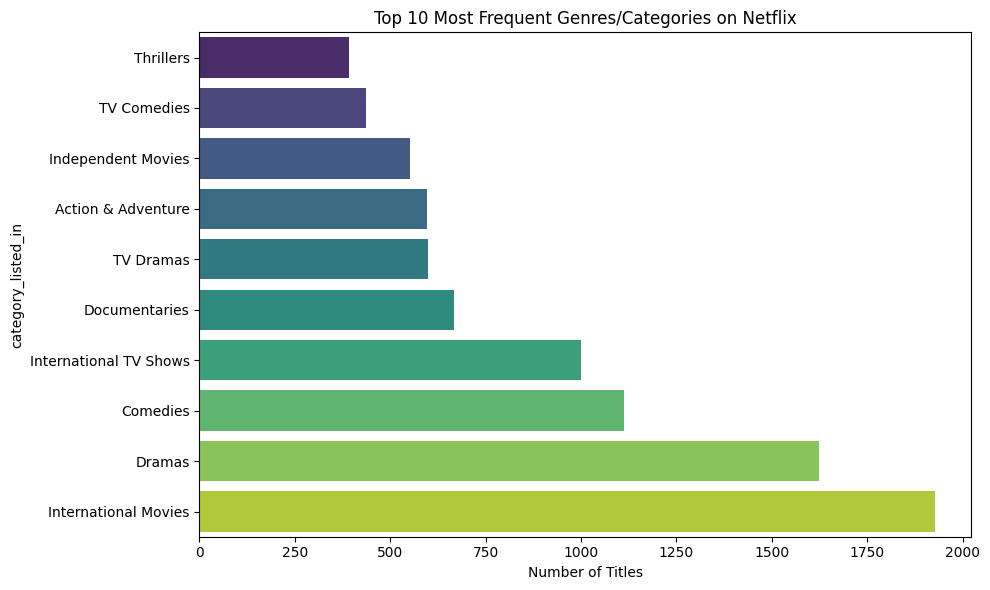

,count
category_listed_in,
Thrillers,392
TV Comedies,436
Independent Movies,552
Action & Adventure,597
TV Dramas,599
Documentaries,667
International TV Shows,1001
Comedies,1112
Dramas,1623


In [179]:
# 2) Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title(title)
plt.xlabel("Number of Titles")
plt.ylabel(col)
plt.tight_layout()
plt.show()

top10

Analytical Question: Based on your visualization, state one clear insight. For example, "The data shows a heavy concentration in the 'International TV Shows' category, suggesting a strategy of global content acquisition."

In [180]:
# Insight from the Top 10 category frequency bar chart

# The visualization shows that a small number of categories dominate the Netflix catalog (for example, categories like International Movies/International TV Shows and
# Dramas/Comedies appear far more frequently than most others). This suggests Netflix’s content strategy is heavily focused on broad-appeal mainstream genres
# and international content acquisition, likely to spread into multiple regions and audience segments.

Save the Model

In [181]:
out_path = "/content/drive/MyDrive/DSA_ICT/Data/netflix_master_clean.csv"
master.to_csv(out_path, index=False)
print("Saved to:", out_path)

Saved to: /content/drive/MyDrive/DSA_ICT/Data/netflix_master_clean.csv
